# Animal Detection and Monitoring System

This project detects animals in images and classifies them using a machine learning based object detection pipeline.

The system can:
• Detect animals in images
• Identify different species
• Trigger alerts for carnivores
• Visualize detections with bounding boxes

Applications:
• Wildlife monitoring
• Forest surveillance
• Animal safety alerts

## Problem Statement

Monitoring wildlife manually is difficult and time-consuming.

This project builds an automated system that detects animals from images and identifies potentially dangerous species (carnivores).

The goal is to create a detection pipeline that can help wildlife monitoring systems automatically analyze camera trap images.

In [2]:
!git clone https://github.com/palak2564/datascience_projects.git
%cd datascience_projects/animal_detection_model
!pip install -r requirements.txt

Cloning into 'datascience_projects'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 48 (delta 7), reused 34 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 1.69 MiB | 5.57 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/datascience_projects/animal_detection_model
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.7 MB/s eta 0:00:00


In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from detector import AnimalDetector

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
detector = AnimalDetector()

print("Animal detection model initialized")

[detector] Loading yolov8n.pt ...
[detector] Model loaded ✓
Animal detection model initialized


In [6]:
from google.colab import files

uploaded = files.upload()

Saving istockphoto-1263462458-612x612.jpg to istockphoto-1263462458-612x612.jpg


In [7]:
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)

print("Image shape:", image.shape)

Image shape: (385, 612, 3)


In [9]:
dir(detector)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_demo_detections',
 '_draw_detections',
 '_draw_summary_overlay',
 '_is_animal',
 '_load_model',
 '_run_inference',
 'detect_image',
 'detect_video',
 'model',
 'model_size']

In [12]:
detections = detector.detect_image("/content/animals.jpg")

print(detections)

{'source': '/content/animals.jpg', 'detections': [{'label': 'giraffe', 'confidence': 0.921, 'bbox': (369, 92, 562, 352), 'is_carnivore': False, 'diet_tag': 'herbivore'}, {'label': 'elephant', 'confidence': 0.903, 'bbox': (84, 123, 317, 364), 'is_carnivore': False, 'diet_tag': 'herbivore'}, {'label': 'zebra', 'confidence': 0.801, 'bbox': (392, 256, 482, 364), 'is_carnivore': False, 'diet_tag': 'herbivore'}, {'label': 'zebra', 'confidence': 0.79, 'bbox': (409, 239, 541, 360), 'is_carnivore': False, 'diet_tag': 'herbivore'}], 'annotated_frame': array([[[246, 167, 100],
        [246, 167, 100],
        [246, 167, 100],
        ...,
        [246, 168, 101],
        [246, 168, 101],
        [246, 168, 101]],

       [[246, 167, 100],
        [246, 167, 100],
        [246, 167, 100],
        ...,
        [246, 168, 101],
        [246, 168, 101],
        [246, 168, 101]],

       [[246, 167, 100],
        [246, 167, 100],
        [246, 167, 100],
        ...,
        [246, 168, 101],
        [

In [13]:
result_image = detections["annotated_frame"]

In [14]:
import cv2
import matplotlib.pyplot as plt

In [15]:
result_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)


Text(0.5, 1.0, 'Animal Detection Results')

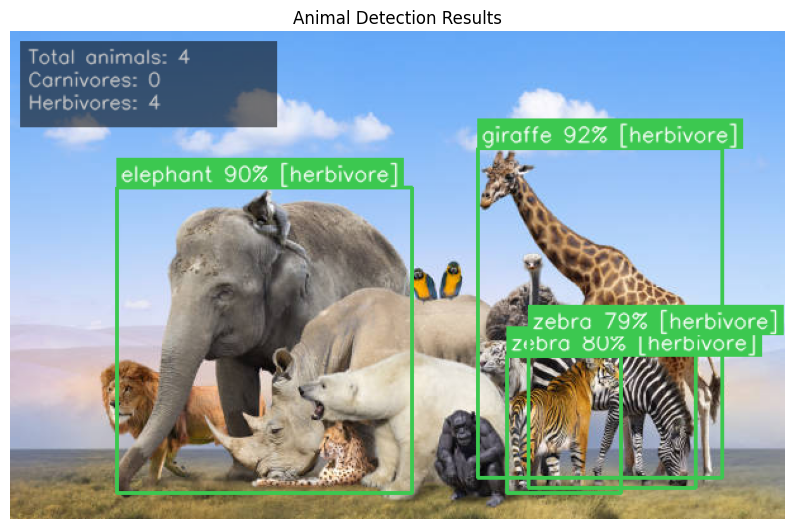

In [16]:
plt.figure(figsize=(10,8))
plt.imshow(result_rgb)
plt.axis("off")
plt.title("Animal Detection Results")

In [17]:
for d in detections["detections"]:
    print(d)

{'label': 'giraffe', 'confidence': 0.921, 'bbox': (369, 92, 562, 352), 'is_carnivore': False, 'diet_tag': 'herbivore'}
{'label': 'elephant', 'confidence': 0.903, 'bbox': (84, 123, 317, 364), 'is_carnivore': False, 'diet_tag': 'herbivore'}
{'label': 'zebra', 'confidence': 0.801, 'bbox': (392, 256, 482, 364), 'is_carnivore': False, 'diet_tag': 'herbivore'}
{'label': 'zebra', 'confidence': 0.79, 'bbox': (409, 239, 541, 360), 'is_carnivore': False, 'diet_tag': 'herbivore'}
